In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils import class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
df = pd.read_csv("fer2013.csv")

print(df.head())
print(df['emotion'].value_counts())

   emotion                                             pixels     Usage
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...  Training
1        0  151 150 147 155 148 133 111 140 170 174 182 15...  Training
2        2  231 212 156 164 174 138 161 173 182 200 106 38...  Training
3        4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...  Training
4        6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...  Training
emotion
3    8989
6    6198
4    6077
2    5121
0    4953
5    4002
1     547
Name: count, dtype: int64


In [4]:
train_df = df[df['Usage'] == 'Training']
val_df = df[df['Usage'] == 'PublicTest']
test_df = df[df['Usage'] == 'PrivateTest']

In [5]:
def process_data(data):
    X, y = [], []
    
    for _, row in data.iterrows():
        pixels = np.array(row['pixels'].split(), dtype='float32')
        image = pixels.reshape(48, 48, 1)
        
        X.append(image)
        y.append(row['emotion'])
    
    return np.array(X), np.array(y)

X_train, y_train = process_data(train_df)
X_val, y_val = process_data(val_df)
X_test, y_test = process_data(test_df)

In [6]:
X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

In [7]:
y_train = to_categorical(y_train, 7)
y_val = to_categorical(y_val, 7)
y_test = to_categorical(y_test, 7)

In [8]:
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(np.argmax(y_train, axis=1)),
    y=np.argmax(y_train, axis=1)
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.0266046844269623), 1: np.float64(9.406618610747051), 2: np.float64(1.0010460615781582), 3: np.float64(0.5684387684387684), 4: np.float64(0.8491274770777877), 5: np.float64(1.293372978330405), 6: np.float64(0.8260394187886635)}


In [9]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

In [10]:
model = Sequential()

# Block 1
model.add(Conv2D(64, (3,3), activation='relu', input_shape=(48,48,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Block 2
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Block 3
model.add(Conv2D(256, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Dense
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(7, activation='softmax'))

c:\Users\jagad\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=30,
    validation_data=(X_val, y_val),
    class_weight=class_weights
)

Epoch 1/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 71s 153ms/step - accuracy: 0.1856 - loss: 2.0486 - val_accuracy: 0.2825 - val_loss: 1.8268
Epoch 2/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 64s 142ms/step - accuracy: 0.2452 - loss: 1.8295 - val_accuracy: 0.1688 - val_loss: 2.2037
Epoch 3/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 65s 144ms/step - accuracy: 0.2898 - loss: 1.7676 - val_accuracy: 0.3583 - val_loss: 1.7011
Epoch 4/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 66s 148ms/step - accuracy: 0.3244 - loss: 1.7180 - val_accuracy: 0.3157 - val_loss: 1.7606
Epoch 5/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 64s 143ms/step - accuracy: 0.3303 - loss: 1.6765 - val_accuracy: 0.3764 - val_loss: 1.5669
Epoch 6/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 66s 147ms/step - accuracy: 0.3471 - loss: 1.6449 - val_accuracy: 0.4160 - val_loss: 1.5879
Epoch 7/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 66s 148ms/step - accuracy: 0.3565 - loss: 1.6254 - val_accuracy: 0.4071 - val_loss: 1.5509
Epoch 8/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 65s 145ms/step - accuracy: 0.3696 - loss: 1

In [13]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5600 - loss: 1.1694
Test Accuracy: 0.5600445866584778


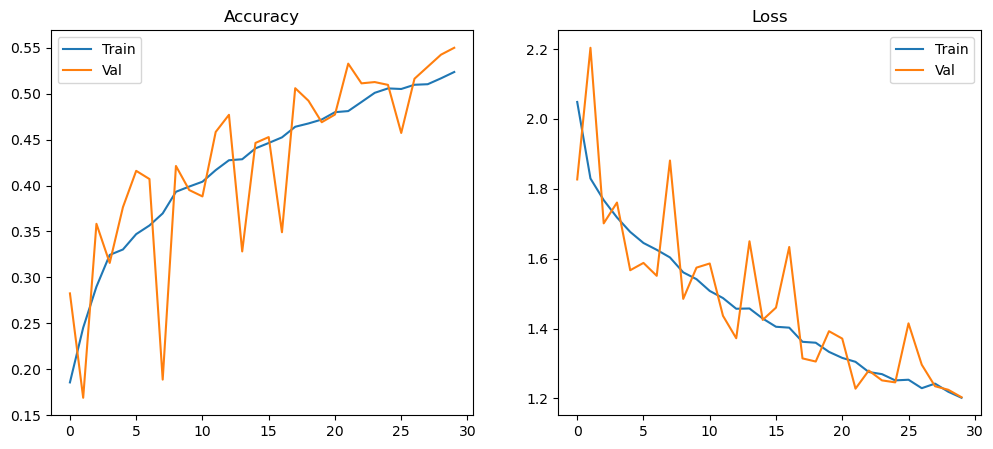

In [14]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss")
plt.legend()

plt.show()

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


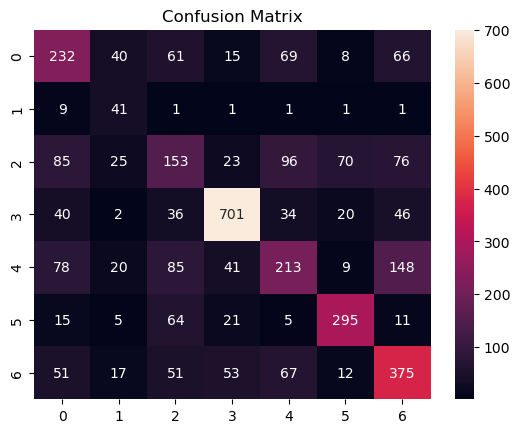

              precision    recall  f1-score   support

           0       0.45      0.47      0.46       491
           1       0.27      0.75      0.40        55
           2       0.34      0.29      0.31       528
           3       0.82      0.80      0.81       879
           4       0.44      0.36      0.39       594
           5       0.71      0.71      0.71       416
           6       0.52      0.60      0.56       626

    accuracy                           0.56      3589
   macro avg       0.51      0.57      0.52      3589
weighted avg       0.56      0.56      0.56      3589



In [16]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred_classes))

In [17]:
model.save("emotion_model_advanced.h5")